<a href="https://colab.research.google.com/github/2023giteshpeswani/MLDL-EXPS/blob/main/MLDL_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_11723/4127254683.py:23: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
First 5 records:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


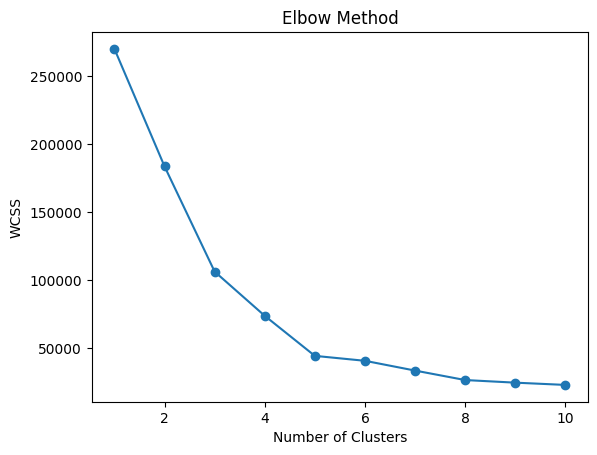

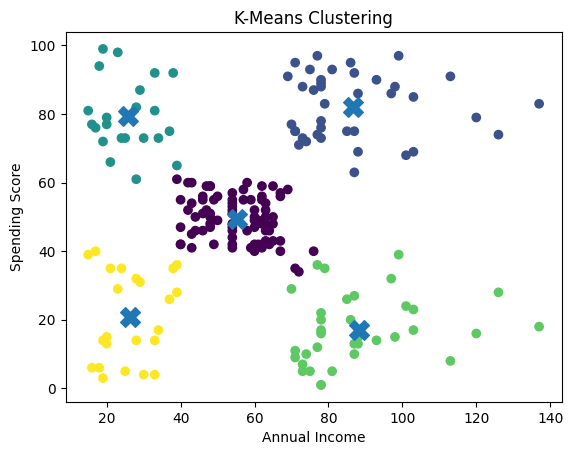

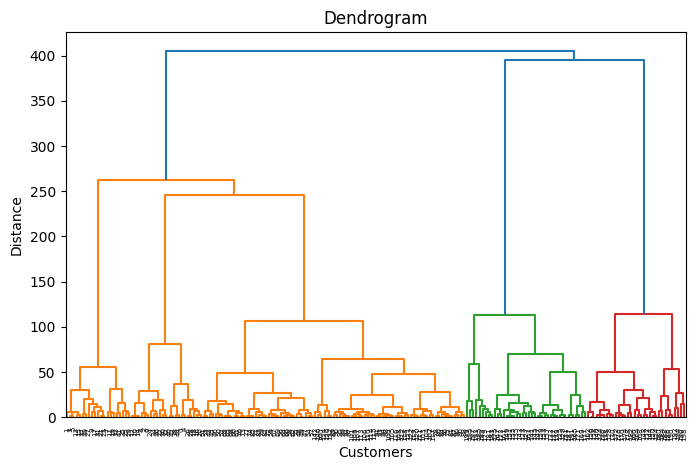

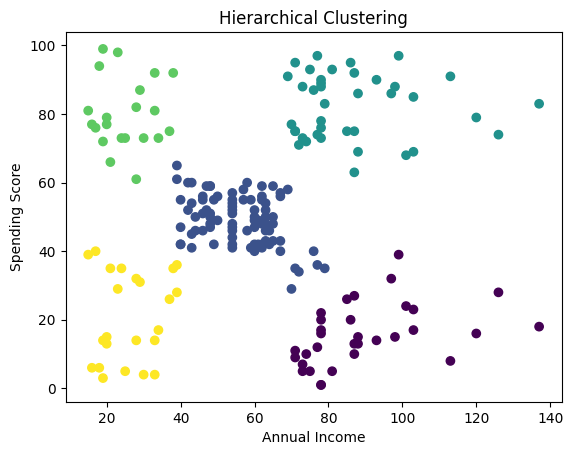


K-Means Silhouette Score: 0.553931997444648
Hierarchical Silhouette Score: 0.5529945955148897


In [1]:
# Install dependency
!pip install kagglehub[pandas-datasets]

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# ============================
# STEP 1: LOAD DATASET
# ============================
file_path = "Mall_Customers.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "vjchoudhary7/customer-segmentation-tutorial-in-python",
    file_path
)

print("First 5 records:\n", df.head())

# ============================
# STEP 2: PREPROCESSING
# ============================
print("\nMissing Values:\n", df.isnull().sum())

# Drop unnecessary column
df.drop("CustomerID", axis=1, inplace=True)

# Encode categorical column
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

# Select features
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

# ============================
# STEP 3: ELBOW METHOD
# ============================
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# ============================
# STEP 4: K-MEANS CLUSTERING
# ============================
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X')

plt.title("K-Means Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

# ============================
# STEP 5: HIERARCHICAL CLUSTERING
# ============================
plt.figure(figsize=(8,5))
sch.dendrogram(sch.linkage(X, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
y_hc = hc.fit_predict(X)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y_hc)

plt.title("Hierarchical Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

# ============================
# STEP 6: EVALUATION
# ============================
print("\nK-Means Silhouette Score:", silhouette_score(X, y_kmeans))
print("Hierarchical Silhouette Score:", silhouette_score(X, y_hc))